<a href="https://colab.research.google.com/github/fphsFischmeister/ILAE_NeuroimagingSchool/blob/master/notebooks/01_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Google Colab"/>  </a>

# Welcome to the interactive ILAE workshop on task-based activation detection.

Author: Florian Ph.S Fischmeister, Marc Berger, Radeshyam Stepponat

---
- Part 1: Preprocessing fMRI data with fMRIPrep
- Part 2: First Level of a simple motor task


In [1]:
# get some data for presentation
!rm -rf ILAE_NeuroimagingSchool
!git clone https://github.com/fphsFischmeister/ILAE_NeuroimagingSchool.git

Cloning into 'ILAE_NeuroimagingSchool'...
remote: Enumerating objects: 127, done.
remote: Counting objects: 100% (61/61), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 127 (delta 28), reused 43 (delta 12), pack-reused 66 (from 2)
Receiving objects: 100% (127/127), 127.96 MiB | 26.33 MiB/s, done.
Resolving deltas: 100% (46/46), done.


In [9]:
# get some functional motor data for presentation
!wget https://dinlab.roentgen.meduniwien.ac.at/ILAE_NeuroimagingSchool/dataset/sub_ILAEDemo001_ses-01_task-MotorHandright_run-01_space-T1w_desc-brain_mask.nii.gz -P ILAE_NeuroimagingSchool/dataset/func/
!wget https://dinlab.roentgen.meduniwien.ac.at/ILAE_NeuroimagingSchool/dataset/sub-ILAEDemo001_ses-01_task-MotorHandright_run-01_space-T1w_desc-preproc_bold.nii.gz -P ILAE_NeuroimagingSchool/dataset/func/


--2026-05-04 23:20:41--  https://dinlab.roentgen.meduniwien.ac.at/ILAE_NeuroimagingSchool/dataset/sub_ILAEDemo001_ses-01_task-MotorHandright_run-01_space-T1w_desc-brain_mask.nii.gz
Resolving dinlab.roentgen.meduniwien.ac.at (dinlab.roentgen.meduniwien.ac.at)... 149.148.226.8
Connecting to dinlab.roentgen.meduniwien.ac.at (dinlab.roentgen.meduniwien.ac.at)|149.148.226.8|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4496 (4.4K) [application/octet-stream]
Saving to: ‘ILAE_NeuroimagingSchool/dataset/func/sub_ILAEDemo001_ses-01_task-MotorHandright_run-01_space-T1w_desc-brain_mask.nii.gz.1’

sub_ILAEDemo001_ses 100%[===================>]   4.39K  --.-KB/s    in 0s      

2026-05-04 23:20:41 (1.98 GB/s) - ‘ILAE_NeuroimagingSchool/dataset/func/sub_ILAEDemo001_ses-01_task-MotorHandright_run-01_space-T1w_desc-brain_mask.nii.gz.1’ saved [4496/4496]



--2026-05-04 23:20:41--  https://dinlab.roentgen.meduniwien.ac.at/ILAE_NeuroimagingSchool/dataset/sub-ILAEDemo001_ses-01_task-MotorHandright_run-01_space-T1w_desc-preproc_bold.nii.gz
Resolving dinlab.roentgen.meduniwien.ac.at (dinlab.roentgen.meduniwien.ac.at)... 149.148.226.8
Connecting to dinlab.roentgen.meduniwien.ac.at (dinlab.roentgen.meduniwien.ac.at)|149.148.226.8|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 349179751 (333M) [application/octet-stream]
Saving to: ‘ILAE_NeuroimagingSchool/dataset/func/sub-ILAEDemo001_ses-01_task-MotorHandright_run-01_space-T1w_desc-preproc_bold.nii.gz.1’

sub-ILAEDemo001_ses 100%[===================>] 333.00M  65.5MB/s    in 5.1s    

2026-05-04 23:20:46 (64.7 MB/s) - ‘ILAE_NeuroimagingSchool/dataset/func/sub-ILAEDemo001_ses-01_task-MotorHandright_run-01_space-T1w_desc-preproc_bold.nii.gz.1’ saved [349179751/349179751]



In [12]:
# install modules
#!pip install pandas


import numpy as np
import pandas as pd
import nibabel as nib

In [15]:

# some basic analysis definitions for later use
task_label = "MotorHandright"
task_tr= 1 # in seconds
smoothing_fwhm = 8 # in mm, for smoothing the data


event_filename = "./ILAE_NeuroimagingSchool/dataset/func/sub-ILAEDemo001_ses-01_task-MotorHandright_run-01_events.tsv"
nifti_filename = "./ILAE_NeuroimagingSchool/dataset/func/sub-ILAEDemo001_ses-01_task-MotorHandright_run-01_space-T1w_desc-preproc_bold.nii.gz"
mask_filename = "./ILAE_NeuroimagingSchool/dataset/func/sub_ILAEDemo001_ses-01_task-MotorHandright_run-01_space-T1w_desc-brain_mask.nii.gz"

# Read the NIfTI header to get the frame time
frame_time = np.arange(nib.load(nifti_filename).shape[3])*task_tr


# Part 2: First Level of a simple motor task

In this notebook, we perform a first-level task-based fMRI analysis of a simple motor paradigm using Nilearn. This analysis builds on the preprocessing notebook: we assume that the raw MRI data have already been preprocessed with fMRIPrep and that the relevant outputs are available in BIDS-Derivatives format. The main inputs are the preprocessed BOLD image, the task events file, the brain mask, and selected confound regressors from fMRIPrep. 

The goal is to estimate, for one participant and one functional run, which brain regions show BOLD signal changes associated with the motor task. To do this, we fit a first-level general linear model, or GLM, which is applied voxel by voxel. The model compares the measured BOLD time series with a predicted BOLD response derived from the experimental paradigm. Events such as motor movement in this case are described in an *events.tsv* file, transformed into predicted BOLD responses by convolution with a haemodynamic response function, or HRF, and combined into a design matrix. The statistical analysis then tests whether a contrast of design-matrix columns explains a significant proportion of the fMRI signal at each brain location.



## Input for this analysis

Here we expect the input dataset to represent the output of fMRIprep.

The expected folder structure is:

````
dataset
├── anat
│   └── sub-ILAEDemo001_ses-01_run-01_desc-preproc_T1w.nii.gz
└── func
    ├── sub-ILAEDemo001_ses-01_task-MotorHandright_run-01_desc-confounds_timeseries.tsv
    ├── sub-ILAEDemo001_ses-01_task-MotorHandright_run-01_events.tsv
    ├── sub-ILAEDemo001_ses-01_task-MotorHandright_run-01_space-T1w_desc-preproc_bold.nii.gz
````
with the following file classes:
```
preproc_bold                 the 4D fMRI time series (BOLD data)
events.tsv                   timing and labels of the task conditions
confounds_timeseries.tsv     nuisance regressors, for example motion parameters
``` 

In [ ]:
# validate that the file is there
!tree ILAE_NeuroimagingSchool/dataset 

ILAE_NeuroimagingSchool/dataset
├── anat
│   └── sub-ILAEDemo001_ses-01_run-01_desc-preproc_T1w.nii.gz
└── func
    ├── sub-ILAEDemo001_ses-01_task-HomeTownWalking_run-01_desc-confounds_timeseries.tsv
    ├── sub-ILAEDemo001_ses-01_task-MotorHandright_run-01_desc-confounds_timeseries.tsv
    ├── sub-ILAEDemo001_ses-01_task-MotorHandright_run-01_events.tsv
    ├── sub-ILAEDemo001_ses-01_task-MotorHandright_run-01_space-T1w_desc-preproc_bold.nii.gz
    ├── sub-ILAEDemo001_ses-01_task-ObjectNaming_run-01_desc-confounds_timeseries.tsv
    ├── sub-ILAEDemo001_ses-01_task-Phrases_run-01_desc-confounds_timeseries.tsv
    └── sub-ILAEDemo001_ses-01_task-VerbGeneration_run-01_desc-confounds_timeseries.tsv

3 directories, 8 files


## The motor task
In a simple motor task, participants are asked to perform a movement during task blocks and remain still during rest blocks. The movement may involve finger tapping, hand opening and closing, foot movement, or another clinically relevant motor action. 

In our hand it is fistclench in an interval of 30 sec. REST, 30 sec. MOTOR, ... for 5 min.

In [ ]:
!ls ILAE_NeuroimagingSchool/dataset/func

sub-ILAEDemo001_ses-01_task-HomeTownWalking_run-01_desc-confounds_timeseries.tsv
sub-ILAEDemo001_ses-01_task-MotorHandright_run-01_desc-confounds_timeseries.tsv
sub-ILAEDemo001_ses-01_task-MotorHandright_run-01_events.tsv
sub-ILAEDemo001_ses-01_task-MotorHandright_run-01_space-T1w_desc-preproc_bold.nii.gz
sub-ILAEDemo001_ses-01_task-ObjectNaming_run-01_desc-confounds_timeseries.tsv
sub-ILAEDemo001_ses-01_task-Phrases_run-01_desc-confounds_timeseries.tsv
sub-ILAEDemo001_ses-01_task-VerbGeneration_run-01_desc-confounds_timeseries.tsv


In [16]:
# load the event file and show content

task_events_data = pd.read_csv(event_filename, sep="\t")
if 'onset' not in task_events_data.columns:
    raise KeyError("Missing 'onset' column in events file")
if 'trial_type' not in task_events_data.columns:
    raise KeyError("Missing 'trial_type' column in events file")
if 'duration' not in task_events_data.columns:
    raise KeyError("Missing 'duration' column in events file")
task_events_data['onset'] = task_events_data['onset'].astype(float)
design_events = pd.DataFrame({
    'trial_type': task_events_data['trial_type'],
    'onset': task_events_data['onset'],
    'duration': task_events_data['duration']
})
print(design_events.head())

  trial_type  onset  duration
0       REST    0.0        30
1      MOTOR   30.0        30
2       REST   60.0        30
3      MOTOR   90.0        30
4       REST  120.0        30


Optionally, the events can be visualized ... not very interesting though

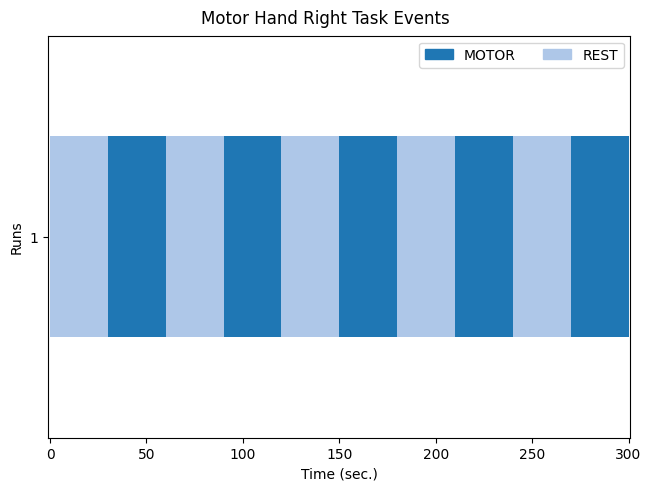

In [17]:
from nilearn.plotting import plot_event, show

fig = plot_event(design_events)
fig.suptitle("Motor Hand Right Task Events")
show()

## Building the design matrix

The design matrix describes the model that will be fitted to the BOLD signal. Each row corresponds to one fMRI volume, and each column corresponds to one model regressor. Task regressors model the expected BOLD response to each condition. Additional columns may model slow scanner drift, head motion, non-steady-state volumes, or other nuisance effects.

The design matrix is the central object of the first-level GLM. It specifies what signal changes we expect to observe during the motor task and which nuisance effects we want to account for. Before fitting or interpreting the model, we thus inspect the design matrix carefully. The motor regressor should follow the timing of the task blocks or events, while drift and confound regressors should capture slow signal fluctuations or motion-related effects. If the design matrix does not match the experimental paradigm, the resulting activation map will not be meaningful.

Here we will use *FirstLevelModel* to generate the design matrix from the events object, fit the model to the fMRI image, and then inspect the resulting design matrix. 

Text(0.5, 1.0, 'Design Matrix - MotorHandright')

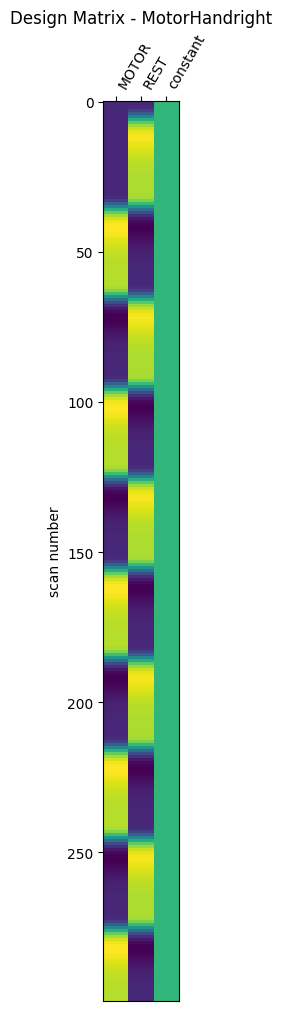

In [19]:
# generate design matrix
from nilearn.glm.first_level import FirstLevelModel, make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix
import matplotlib.pyplot as plt


design_matrix = make_first_level_design_matrix(
    frame_times=frame_time,
    events=design_events,
    hrf_model='spm',
    drift_model=None)

# Plot the design matrix
plot_design_matrix(design_matrix)
plt.title(f"Design Matrix - {task_label}")

Text(0.5, 1.0, 'Design Matrix Correlation for task - MotorHandright')

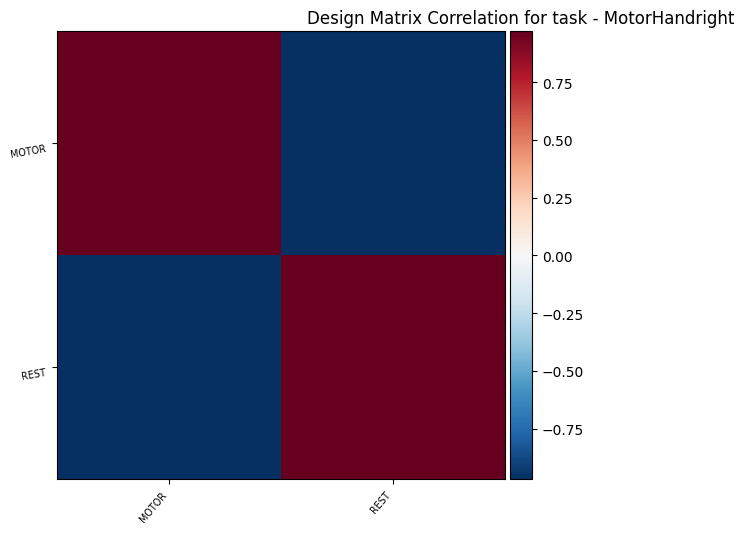

In [21]:
# plot correlation between regressors
from nilearn.plotting import plot_design_matrix_correlation
plot_design_matrix_correlation(design_matrix)
plt.title(f"Design Matrix Correlation for task - {task_label}")

In [24]:
# using ar1 autocorrelation (FSL prewhitening), drift model
fmri_glm = FirstLevelModel(subject_label='sub-ILAEDemo001', mask_img=mask_filename,
                            t_r=task_tr, smoothing_fwhm=smoothing_fwhm,
                            standardize=False, noise_model='ar1', drift_model=None, high_pass=None
                            )
# Run GLM model using set paths and calculate design matrix
fmri_glm = fmri_glm.fit(nifti_filename, design_matrices=design_matrix)

/tmp/ipykernel_1331338/199875976.py:7: UserWarning: If design matrices are supplied, [drift_model, high_pass, t_r] will be ignored.
  fmri_glm = fmri_glm.fit(nifti_filename, design_matrices=design_matrix)


In [ ]:
# Compute z-score of specified contrast and save to file
contrast = [ 1 -1]
zscore_filename = Path(
    output_dir) / f"{subject}_task-{task_label}_run-{1}_contrast-{contrast[0]}_z-score.nii.gz"

zscore_est = fmri_glm.compute_contrast(
    contrast[1], output_type="z_score")
            zscore_est.to_filename(zscore_filename)
